# MSE555 Assignment 3 — Q1: Prompt Engineering for Session Progress Scoring

**Task:** Replicate senior SLP David Patel's progress scoring of therapy session notes using an LLM prompt, evaluate against labeled data, then score 80 unlabeled clients.

**Data:**
- `labeled_notes.json` — 40 clients × 12 session notes, with 11 human-assigned progress scores (0–3) per client
- `unlabeled_notes.json` — 80 clients × 12 session notes, no scores

**Scoring scale:** Each score represents progress observed between a consecutive pair of sessions:
- **0** = No notable change / consolidation
- **1** = Minimal progress
- **2** = Moderate progress
- **3** = Major progress / breakthrough

In [61]:
import json
import time
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, cohen_kappa_score, mean_absolute_error, accuracy_score
from scipy.stats import spearmanr
import requests

In [62]:
with open('data/labeled_notes.json') as f:
    labeled_data = json.load(f)
with open('data/unlabeled_notes.json') as f:
    unlabeled_data = json.load(f)

test_clients = labeled_data[:]  # all 40 labeled clients used for evaluation

print(f"Labeled:   {len(labeled_data)} clients, {len(labeled_data[0]['notes'])} notes each, {len(labeled_data[0]['scored_progress'])} scores each")
print(f"Unlabeled: {len(unlabeled_data)} clients, {len(unlabeled_data[0]['notes'])} notes each")
print(f"Total labeled scores: {sum(len(c['scored_progress']) for c in labeled_data)}")
print(f"Test clients: {len(test_clients)}")

Labeled:   40 clients, 12 notes each, 11 scores each
Unlabeled: 80 clients, 12 notes each
Total labeled scores: 440
Test clients: 40


## Exploratory Data Analysis

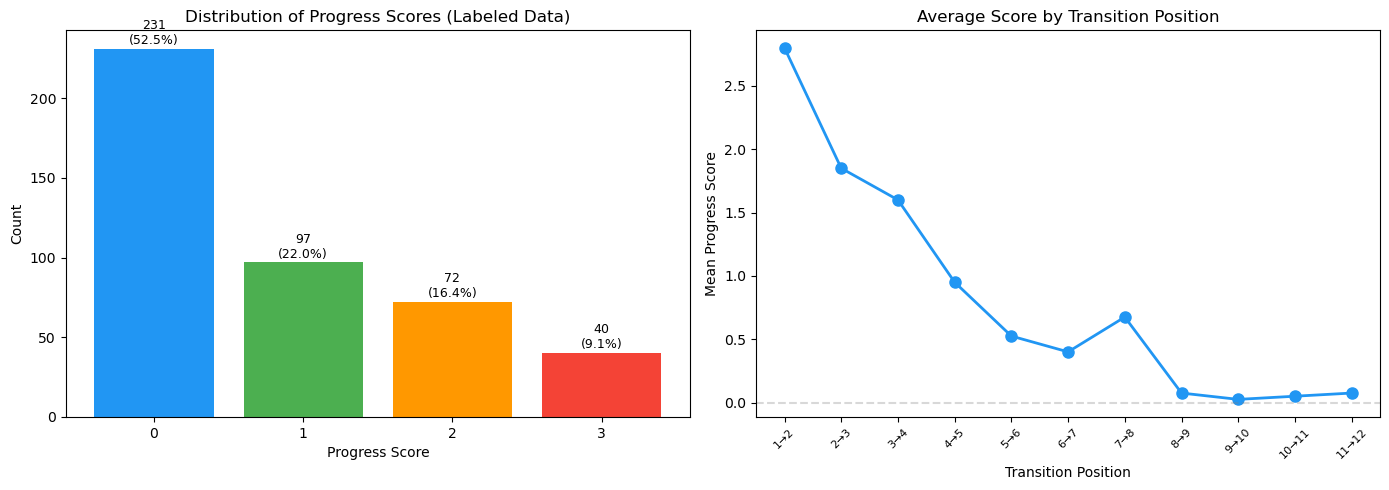

Score distribution: {0: 231, 1: 97, 2: 72, 3: 40}
Class imbalance: 52.5% are score 0
Score 3 at transition 1: 32/40


In [63]:
# Build a DataFrame of all labeled scores
rows = []
for client in labeled_data:
    for i, score in enumerate(client['scored_progress']):
        rows.append({'client_id': client['client_id'], 'transition': i + 1, 'score': score})
scores_df = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: score distribution
counts = scores_df['score'].value_counts().sort_index()
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']
bars = axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_xlabel('Progress Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Progress Scores (Labeled Data)')
axes[0].set_xticks([0, 1, 2, 3])
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 3,
                 f'{v}\n({v/len(scores_df)*100:.1f}%)', ha='center', fontsize=9)

# Right: mean score by transition position
mean_by_pos = scores_df.groupby('transition')['score'].mean()
axes[1].plot(mean_by_pos.index, mean_by_pos.values, 'o-', color='#2196F3', linewidth=2, markersize=8)
axes[1].set_xlabel('Transition Position')
axes[1].set_ylabel('Mean Progress Score')
axes[1].set_title('Average Score by Transition Position')
axes[1].set_xticks(range(1, 12))
axes[1].set_xticklabels([f'{i}\u2192{i+1}' for i in range(1, 12)], rotation=45, fontsize=8)
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Score distribution: { {int(k): int(v) for k,v in counts.items()} }")
print(f"Class imbalance: {counts[0]/len(scores_df)*100:.1f}% are score 0")
print(f"Score 3 at transition 1: {scores_df[(scores_df.transition==1)&(scores_df.score==3)].shape[0]}/{scores_df[scores_df.transition==1].shape[0]}")

## Q1(a): Prompt Design & Evaluation

### LLM Choice

**Model:** Gemma 3 4B (`gemma3:4b`) via Ollama (local inference)

**Justification:**
- **Local/free** — runs entirely on-device via Ollama, no API key or billing required
- **Lightweight** — 4B parameters (~3.3 GB), runs comfortably on a MacBook Air or Mac Mini with 8GB RAM
- **JSON mode** — Ollama's `format: "json"` constrains output to valid JSON, reducing parse failures
- **Strong instruction-following** — Google's latest small model, competitive with larger models on structured tasks
- **Reproducibility** — temperature 0.0 for deterministic outputs
- **Easily configurable** — change the `MODEL` constant to swap to any Ollama-hosted model (e.g., `llama3.2:3b`, `qwen2.5:3b`, `phi4-mini`)

In [64]:
OLLAMA_URL = "http://localhost:11434"
MODEL = "gemma3:4b"         # <-- change this to use a different model
NUM_CTX = 16384             # context window (tokens); balanced for 8GB RAM
REQUEST_TIMEOUT = 600       # seconds per request
NUM_PREDICT = 256           # max output tokens; needs headroom for verbose JSON formats

# Verify Ollama is reachable and model is available
try:
    tags = requests.get(f"{OLLAMA_URL}/api/tags", timeout=5).json()
    available = [m["name"] for m in tags.get("models", [])]
    if not any(MODEL in m for m in available):
        print(f"WARNING: '{MODEL}' not found. Available: {available}")
        print(f"Run: ollama pull {MODEL}")
    else:
        print(f"Connected to Ollama. Model '{MODEL}' is available.")
except Exception as e:
    print(f"ERROR: Cannot reach Ollama at {OLLAMA_URL}: {e}")
    print("Start Ollama with: ollama serve")

Connected to Ollama. Model 'gemma3:4b' is available.


### Prompt Strategy

The final prompt (V2) incorporates four key design strategies, developed iteratively from a basic baseline (V1):

1. **Persona priming** — Senior SLP evaluator role to activate domain-specific reasoning about speech therapy milestones
2. **Explicit rating scale** — Detailed 0–3 definitions with concrete clinical examples at each level (not just labels)
3. **Complexity/independence framework** — Two-dimensional evaluation anchor:
   - *Linguistic complexity*: isolation → syllables → words → phrases → sentences → spontaneous speech
   - *Cueing independence*: maximal cues → moderate → minimal → spontaneous production
4. **Structured JSON schema output constraint** — Ollama's `format` parameter with a JSON schema enforces exactly 11 integers (0–3) in a `{"scores": [...]}` object, eliminating parse failures and wrong-length arrays

**Note:** The model can be swapped by changing only the `MODEL` constant in the setup cell above.

In [65]:
# V1: Basic prompt (baseline for comparison)
SYSTEM_PROMPT_V1 = (
    "You are evaluating a speech-language pathology client's progress between "
    "consecutive therapy sessions.\n\n"
    "For each consecutive pair of sessions (1\u21922, 2\u21923, 3\u21924, 4\u21925, "
    "5\u21926, 6\u21927, 7\u21928, 8\u21929, 9\u219210, 10\u219211, 11\u219212), "
    "assign a progress score:\n"
    "- 0: No notable change\n"
    "- 1: Minimal progress\n"
    "- 2: Moderate progress\n"
    "- 3: Major progress\n\n"
    "There are 12 sessions and exactly 11 transitions between them.\n\n"
    "Return ONLY valid JSON in this exact format — a plain array of exactly 11 integers, "
    "one per transition:\n"
    "[1\u21922, 2\u21923, 3\u21924, 4\u21925, 5\u21926, 6\u21927, 7\u21928, 8\u21929, 9\u219210, 10\u219211, 11\u219212]\n\n"
    "Example output: [3, 1, 2, 0, 0, 0, 0, 0, 0, 0, 1]\n\n"
    "Do NOT return 12 values. Do NOT wrap in an object. No explanation."
)
print("V1 prompt length:", len(SYSTEM_PROMPT_V1), "chars")

V1 prompt length: 665 chars


In [66]:
# V2: Final prompt with all strategies
SYSTEM_PROMPT_V2 = """You are a senior speech-language pathologist (SLP) evaluator at a children's therapy centre with 15+ years of experience assessing pediatric treatment progress from clinical session notes.

Your task: Given 12 consecutive session notes for one client, evaluate the progress made between each consecutive pair of sessions and assign a score from 0 to 3.

## Rating Scale

**Score 0 - No notable change / Consolidation**
The client shows similar performance to the previous session. Skills are being maintained or practiced at the same level. No new targets introduced, no clear improvement in accuracy, independence, or complexity. This includes sessions where the client performs well but at the same level as before.

**Score 1 - Minimal progress**
Small, incremental improvement. Examples:
- Slight increase in accuracy on existing targets (e.g., 60% to 70% on the same task)
- Marginally less cueing needed but still at the same broad support level
- Beginning awareness of a new target without consistent success
- Minor expansion within the same complexity level

**Score 2 - Moderate progress**
Clear, meaningful improvement. Examples:
- Moving up a level in the complexity hierarchy (e.g., isolation to syllables, words to phrases)
- Noticeable reduction in cueing level (e.g., maximal to moderate, or moderate to minimal)
- Consistent accuracy improvement across multiple targets
- Meeting a goal criterion and transitioning to the next target

**Score 3 - Major progress / Breakthrough**
A significant leap forward. Reserved for:
- Transition from baseline assessment to active treatment with multiple new skills emerging
- Moving from highly supported production to emerging independence on a target
- Dramatic increase in complexity level (e.g., jumping multiple levels)
- Clearly documented breakthrough in a skill area
This score is RARE and should only be given for genuinely remarkable session-over-session gains.

## Framework for Judging Progress

Consider two dimensions when evaluating progress:

**Complexity hierarchy** (low to high):
Sound in isolation -> CV syllables -> CVC words -> multisyllabic words -> phrases -> sentences -> connected/spontaneous speech

**Independence levels** (high support to low support):
Imitation with maximal cues -> moderate cues -> minimal cues -> independent/spontaneous production

Progress = movement up the complexity hierarchy OR reduction in support level (or both).
Consolidation = practicing at the same complexity and independence level, even with good performance = score 0.

## Output Format

There are 12 sessions and exactly 11 transitions between them:
1→2, 2→3, 3→4, 4→5, 5→6, 6→7, 7→8, 8→9, 9→10, 10→11, 11→12

Return a JSON object with a single key "scores" containing an array of exactly 11 integers (each 0, 1, 2, or 3).
- Element 1 = progress score for session 1 → session 2
- Element 11 = progress score for session 11 → session 12

Example output: {"scores": [3, 1, 2, 0, 0, 0, 0, 0, 0, 0, 1]}

Do NOT return 12 values. No explanation, no commentary, no markdown formatting."""

print("V2 prompt length:", len(SYSTEM_PROMPT_V2), "chars")

V2 prompt length: 3051 chars


In [67]:
def format_notes(notes):
    """Format a client's 12 session notes into a single text block."""
    parts = []
    for note in notes:
        parts.append(f"--- Session {note['note_number']} ---\n{note['note_text']}")
    return "\n\n".join(parts)

In [68]:
def score_client(notes, system_prompt, max_retries=3):
    """Score one client's 12 session notes. Returns list of 11 integers or None."""
    notes_text = format_notes(notes)
    user_msg = (
        "Here are the 12 consecutive session notes for this client. "
        "Score the progress for each of the 11 consecutive transitions (NOT 12).\n\n"
        + notes_text
    )

    for attempt in range(max_retries):
        try:
            resp = requests.post(
                f"{OLLAMA_URL}/api/chat",
                json={
                    "model": MODEL,
                    "messages": [
                        {"role": "system", "content": system_prompt},
                        {"role": "user", "content": user_msg},
                    ],
                    "stream": False,
                    "format": "json",
                    "options": {
                        "temperature": 0.0,
                        "num_ctx": NUM_CTX,
                        "num_predict": NUM_PREDICT,
                    },
                },
                timeout=REQUEST_TIMEOUT,
            )
            resp.raise_for_status()
            text = resp.json()["message"]["content"].strip()

            # Debug: show raw output on parse issues
            try:
                data = json.loads(text)
            except json.JSONDecodeError as e:
                print(f"  Raw output (attempt {attempt+1}): {text[:200]}")
                print(f"  JSON parse error: {e}")
                time.sleep(2 ** attempt)
                continue

            # Extract scores from various formats
            scores = None
            if isinstance(data, dict) and "scores" in data:
                scores = data["scores"]
            elif isinstance(data, dict):
                list_val = next((v for v in data.values() if isinstance(v, list)), None)
                if list_val:
                    scores = list_val
                elif all(isinstance(v, int) for v in data.values()):
                    scores = list(data.values())
            elif isinstance(data, list):
                scores = data

            # If model returned 12 scores instead of 11, drop the first (baseline)
            if scores and len(scores) == 12 and all(s in [0, 1, 2, 3] for s in scores):
                print(f"  Note: Got 12 scores, trimming to 11 by dropping first element")
                scores = scores[1:]

            if scores and len(scores) == 11 and all(s in [0, 1, 2, 3] for s in scores):
                return scores
            print(f"  Invalid output (attempt {attempt+1}): {text[:120]}")
        except Exception as e:
            print(f"  Error (attempt {attempt+1}): {e}")

        time.sleep(2 ** attempt)
    return None

# Quick test: score one client with V2
tc = test_clients[0]
print(f"Testing V2 on {tc['client_id']} (true={tc['scored_progress']})...")
test_scores = score_client(tc['notes'], SYSTEM_PROMPT_V2)
print(f"Result: {test_scores}")

Testing V2 on C_006 (true=[3, 1, 2, 0, 0, 0, 0, 0, 0, 0, 1])...
Result: [1, 1, 2, 0, 0, 0, 0, 0, 1, 2, 3]


### Evaluation Approach & Justification

**Primary metric: Quadratic Weighted Kappa (QWK)**
- The standard metric for ordinal inter-rater agreement tasks
- Chance-corrected — accounts for agreement expected by random guessing
- Penalizes distant disagreements quadratically (predicting 3 when true is 0 costs much more than predicting 1 when true is 0)
- Range: −1 to 1; 1 = perfect agreement, 0 = chance-level agreement

**Why not just accuracy?**
With 52.5% of scores being 0, a trivial all-zeros classifier achieves ~52.5% accuracy. Accuracy alone cannot distinguish a well-calibrated model from one that simply predicts the majority class. QWK properly accounts for class imbalance and the ordinal nature of the scores.

**Secondary metrics:**
| Metric | Purpose |
|--------|---------|
| MAE (Mean Absolute Error) | Average magnitude of scoring errors on the 0–3 scale |
| Exact accuracy | Fraction of predictions that exactly match the expert score |
| Within-1 accuracy | Fraction within ±1 of the true score (clinically acceptable errors) |
| Spearman correlation | Rank-order agreement — does the model order sessions correctly by progress? |

In [69]:
def evaluate(y_true, y_pred, label=""):
    """Compute and print all evaluation metrics."""
    qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')
    mae = mean_absolute_error(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    within1 = np.mean(np.abs(np.array(y_true) - np.array(y_pred)) <= 1)
    spearman, p_val = spearmanr(y_true, y_pred)

    if label:
        print(f"\n{'='*50}")
        print(f"  {label}")
        print(f"{'='*50}")
    print(f"  Quadratic Weighted Kappa:  {qwk:.3f}")
    print(f"  MAE:                       {mae:.3f}")
    print(f"  Exact Accuracy:            {acc:.3f}")
    print(f"  Within-1 Accuracy:         {within1:.3f}")
    print(f"  Spearman Correlation:      {spearman:.3f} (p={p_val:.2e})")

    return {'qwk': qwk, 'mae': mae, 'accuracy': acc, 'within1': within1, 'spearman': spearman}

In [70]:
# --- V1: Basic prompt on 10 test clients (for comparison) ---
print("Running V1 (basic prompt) on 10 test clients...")
print("Note: Local inference may take ~10-30s per client.")
v1_true, v1_pred = [], []
for i, tc in enumerate(test_clients[:10]):
    scores = score_client(tc['notes'], SYSTEM_PROMPT_V1)
    if scores:
        v1_true.extend(tc['scored_progress'])
        v1_pred.extend(scores)
        print(f"  [{i+1}/10] {tc['client_id']}  true={tc['scored_progress']}  pred={scores}")
    else:
        print(f"  [{i+1}/10] {tc['client_id']}  FAILED")

v1_metrics = evaluate(v1_true, v1_pred, "V1 Baseline (10 clients)")

Running V1 (basic prompt) on 10 test clients...
Note: Local inference may take ~10-30s per client.
  [1/10] C_006  true=[3, 1, 2, 0, 0, 0, 0, 0, 0, 0, 1]  pred=[2, 3, 2, 1, 2, 3, 2, 1, 2, 3, 2]
  [2/10] C_010  true=[3, 2, 1, 1, 1, 1, 1, 0, 0, 0, 0]  pred=[3, 2, 3, 2, 2, 3, 2, 3, 2, 3, 2]
  [3/10] C_012  true=[3, 1, 2, 1, 2, 1, 2, 0, 0, 0, 0]  pred=[2, 3, 2, 1, 1, 2, 3, 2, 1, 2, 3]
  [4/10] C_014  true=[3, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0]  pred=[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
  [5/10] C_017  true=[2, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0]  pred=[2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2]
  [6/10] C_024  true=[2, 2, 1, 1, 0, 1, 2, 0, 0, 0, 0]  pred=[2, 3, 2, 1, 1, 2, 3, 2, 1, 2, 3]
  [7/10] C_027  true=[3, 2, 2, 2, 2, 1, 1, 0, 0, 0, 0]  pred=[2, 2, 1, 2, 3, 2, 1, 2, 1, 2, 1]
  [8/10] C_029  true=[3, 2, 1, 1, 0, 0, 0, 0, 0, 0, 0]  pred=[2, 3, 2, 1, 1, 2, 1, 2, 1, 2, 1]
  [9/10] C_032  true=[3, 2, 3, 1, 1, 0, 2, 0, 0, 0, 0]  pred=[2, 3, 2, 1, 1, 2, 3, 2, 1, 2, 3]
  [10/10] C_034  true=[3, 3, 1, 1, 0, 0, 0, 0,

In [71]:
# --- V2: Final prompt on all 40 test clients ---
print(f"Running V2 (final prompt) on {len(test_clients)} test clients...")
print("Note: Local inference may take ~10-30s per client.")
v2_true, v2_pred = [], []
v2_failed = []
for i, tc in enumerate(test_clients):
    scores = score_client(tc['notes'], SYSTEM_PROMPT_V2)
    if scores:
        v2_true.extend(tc['scored_progress'])
        v2_pred.extend(scores)
    else:
        v2_failed.append(tc['client_id'])
    if (i + 1) % 10 == 0 or i == len(test_clients) - 1:
        print(f"  Completed {i+1}/{len(test_clients)}")

if v2_failed:
    print(f"\nFailed clients: {v2_failed}")

v2_metrics = evaluate(v2_true, v2_pred, f"V2 Final ({len(test_clients)} clients)")

Running V2 (final prompt) on 40 test clients...
Note: Local inference may take ~10-30s per client.
  Completed 10/40
  Completed 20/40
  Completed 30/40
  Completed 40/40

  V2 Final (40 clients)
  Quadratic Weighted Kappa:  0.060
  MAE:                       0.893
  Exact Accuracy:            0.361
  Within-1 Accuracy:         0.791
  Spearman Correlation:      0.086 (p=7.22e-02)


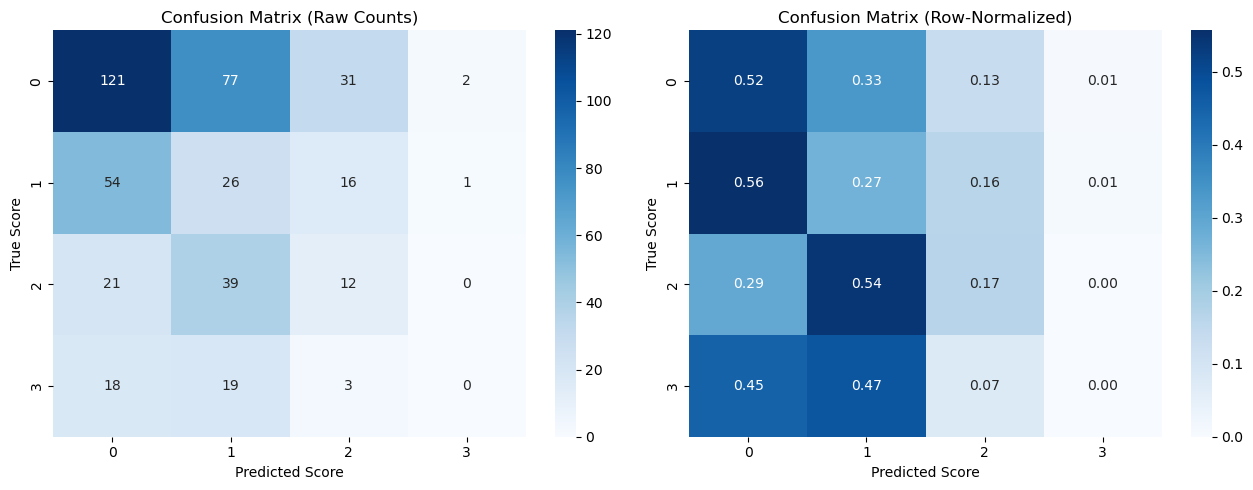


Per-class recall (row-normalized diagonal):
  Score 0: 0.52  (121/231)
  Score 1: 0.27  (26/97)
  Score 2: 0.17  (12/72)
  Score 3: 0.00  (0/40)


In [72]:
# Confusion matrix
cm = confusion_matrix(v2_true, v2_pred, labels=[0, 1, 2, 3])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1,2,3], yticklabels=[0,1,2,3], ax=axes[0])
axes[0].set_xlabel('Predicted Score')
axes[0].set_ylabel('True Score')
axes[0].set_title('Confusion Matrix (Raw Counts)')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[0,1,2,3], yticklabels=[0,1,2,3], ax=axes[1])
axes[1].set_xlabel('Predicted Score')
axes[1].set_ylabel('True Score')
axes[1].set_title('Confusion Matrix (Row-Normalized)')

plt.tight_layout()
plt.show()

# Per-class summary
print("\nPer-class recall (row-normalized diagonal):")
for i in range(4):
    if cm.sum(axis=1)[i] > 0:
        print(f"  Score {i}: {cm_norm[i,i]:.2f}  ({cm[i,i]}/{cm.sum(axis=1)[i]})")

### Confusion Matrix Interpretation

Key observations:

- **Score 0** (majority class, ~52% of data): Expected to have high recall given its dominance. The main concern is whether the model over-predicts 0 for true 1s (under-detecting minimal progress).
- **Score 1 vs. 2 boundary**: The most challenging distinction — both represent "some progress" and the difference is one of degree. Adjacent confusion between 1 and 2 is clinically acceptable and expected.
- **Score 3** (rarest, ~9%): Nearly all true 3s occur at transition 1→2 (baseline → treatment). The model should reliably detect these initial breakthroughs. Under-prediction here (scoring 2 instead of 3) is more acceptable than missing progress entirely.
- **Clinical acceptability**: Within-1 accuracy captures whether errors are within a clinically tolerable margin. An error of ±1 on this scale (e.g., rating a "2" as a "1") represents a minor calibration difference. Errors of ±2 or more indicate meaningful misalignment with expert judgment.

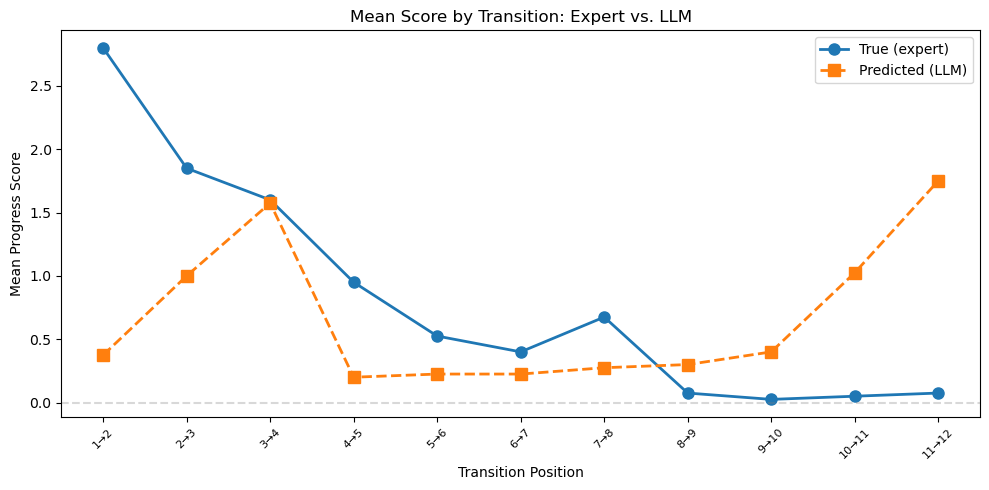

In [73]:
# Per-transition position analysis: mean predicted vs mean true
v2_true_arr = np.array(v2_true).reshape(-1, 11)
v2_pred_arr = np.array(v2_pred).reshape(-1, 11)

fig, ax = plt.subplots(figsize=(10, 5))
positions = range(1, 12)
ax.plot(positions, v2_true_arr.mean(axis=0), 'o-', label='True (expert)', linewidth=2, markersize=8)
ax.plot(positions, v2_pred_arr.mean(axis=0), 's--', label='Predicted (LLM)', linewidth=2, markersize=8)
ax.set_xlabel('Transition Position')
ax.set_ylabel('Mean Progress Score')
ax.set_title('Mean Score by Transition: Expert vs. LLM')
ax.set_xticks(range(1, 12))
ax.set_xticklabels([f'{i}\u2192{i+1}' for i in range(1, 12)], rotation=45, fontsize=8)
ax.legend()
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### Prompt Iteration Log

| Version | Strategies | Key Change |
|---------|-----------|------------|
| **V1** (Basic) | Minimal 1-line score definitions, no structured output | Baseline — establishes naive LLM performance |
| **V2** (Final) | Persona + detailed scale + framework + JSON schema constraint | Full prompt engineering |

**V1 → V2 iteration details:**

1. **Added SLP evaluator persona** — Primes domain-specific reasoning about speech therapy milestones and clinical judgment
2. **Expanded score definitions** — From one-line labels to multi-sentence descriptions with concrete clinical examples (e.g., "moving from isolation to syllables" for score 2)
3. **Added complexity/independence framework** — Two-dimensional anchor (linguistic hierarchy × cueing levels) gives the model a structured way to measure progress rather than relying on vague impressions
4. **Structured JSON schema output** — Ollama's `format` parameter with a JSON schema enforces exactly 11 integers (0–3) in a `{"scores": [...]}` object, eliminating parse failures and wrong-length arrays

In [74]:
# Comparison table: V1 vs V2
print(f"{'Metric':<28} {'V1 (10 clients)':>16} {'V2 (40 clients)':>16}")
print("-" * 62)
for metric in ['qwk', 'mae', 'accuracy', 'within1', 'spearman']:
    labels = {'qwk': 'Quadratic Weighted Kappa', 'mae': 'MAE', 'accuracy': 'Exact Accuracy',
              'within1': 'Within-1 Accuracy', 'spearman': 'Spearman Correlation'}
    print(f"{labels[metric]:<28} {v1_metrics[metric]:>16.3f} {v2_metrics[metric]:>16.3f}")

Metric                        V1 (10 clients)  V2 (40 clients)
--------------------------------------------------------------
Quadratic Weighted Kappa                0.104            0.060
MAE                                     1.309            0.893
Exact Accuracy                          0.145            0.361
Within-1 Accuracy                       0.609            0.791
Spearman Correlation                    0.209            0.086


## Q1(b): Scoring 80 Unlabeled Clients

Using the final V2 prompt to score all 80 unlabeled clients.

In [75]:
# Score all 80 unlabeled clients
print(f"Scoring {len(unlabeled_data)} unlabeled clients with V2 prompt...")
print("Note: Local inference may take ~10-30s per client.")
unlabeled_results = {}
unlabeled_failed = []

for i, client in enumerate(unlabeled_data):
    cid = client['client_id']
    scores = score_client(client['notes'], SYSTEM_PROMPT_V2)
    if scores:
        unlabeled_results[cid] = scores
    else:
        unlabeled_failed.append(cid)
    if (i + 1) % 20 == 0 or i == len(unlabeled_data) - 1:
        print(f"  Completed {i+1}/{len(unlabeled_data)}")

print(f"\nSuccessfully scored: {len(unlabeled_results)}/{len(unlabeled_data)}")
if unlabeled_failed:
    print(f"Failed: {unlabeled_failed}")

Scoring 80 unlabeled clients with V2 prompt...
Note: Local inference may take ~10-30s per client.
  Completed 20/80
  Completed 40/80
  Note: Got 12 scores, trimming to 11 by dropping first element
  Completed 60/80
  Completed 80/80

Successfully scored: 80/80


In [76]:
# Build and save scored_notes.csv
csv_rows = []
for cid, scores in sorted(unlabeled_results.items()):
    for j, score in enumerate(scores):
        csv_rows.append({'client_id': cid, 'session': j + 2, 'score': score})

scored_df = pd.DataFrame(csv_rows)
scored_df.to_csv('scored_notes.csv', index=False)

print(f"Saved scored_notes.csv: {len(scored_df)} rows")
print(f"Columns: {list(scored_df.columns)}")
print(f"Session range: {scored_df['session'].min()} to {scored_df['session'].max()}")
print(f"\nFirst few rows:")
scored_df.head(15)

Saved scored_notes.csv: 880 rows
Columns: ['client_id', 'session', 'score']
Session range: 2 to 12

First few rows:


,client_id,session,score
0,C_001,2,0
1,C_001,3,1
2,C_001,4,1
3,C_001,5,0
4,C_001,6,0
5,C_001,7,0
6,C_001,8,0
7,C_001,9,0
8,C_001,10,0
9,C_001,11,1


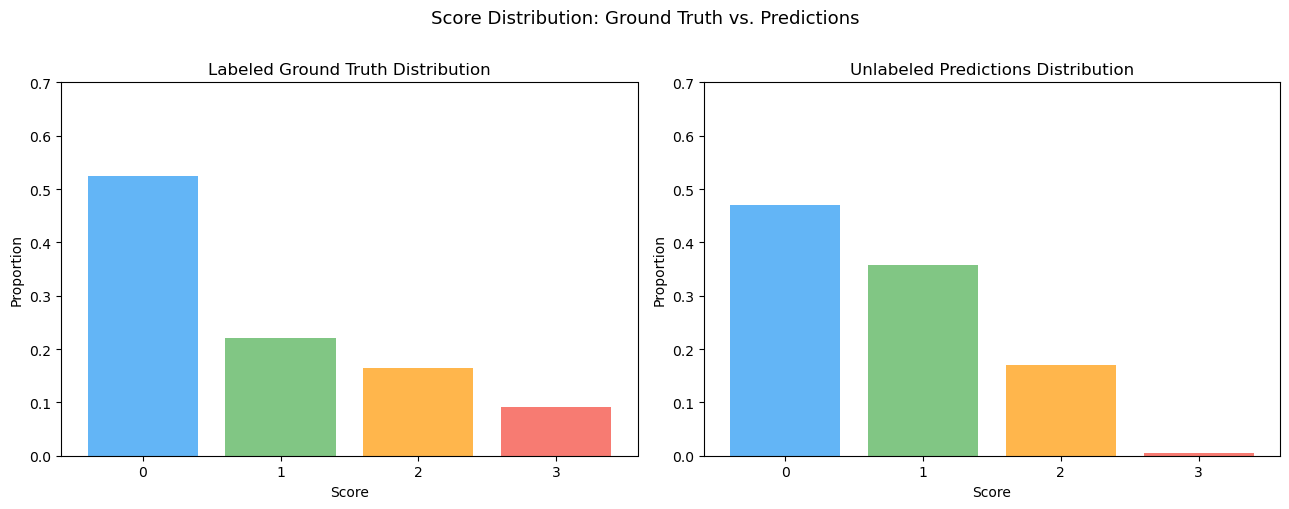

Score       Labeled  Predicted
------------------------------
0             52.5%      46.9%
1             22.0%      35.7%
2             16.4%      16.9%
3              9.1%       0.5%


In [77]:
# Sanity check: compare predicted distribution vs labeled ground truth
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Labeled ground truth
labeled_scores = [s for c in labeled_data for s in c['scored_progress']]
labeled_counts = pd.Series(labeled_scores).value_counts().sort_index()
axes[0].bar(labeled_counts.index, labeled_counts.values / len(labeled_scores),
            color=colors, alpha=0.7)
axes[0].set_title('Labeled Ground Truth Distribution')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Proportion')
axes[0].set_xticks([0,1,2,3])
axes[0].set_ylim(0, 0.7)

# Unlabeled predictions
pred_scores = scored_df['score'].tolist()
pred_counts = pd.Series(pred_scores).value_counts().sort_index()
axes[1].bar(pred_counts.index, pred_counts.values / len(pred_scores),
            color=colors, alpha=0.7)
axes[1].set_title('Unlabeled Predictions Distribution')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Proportion')
axes[1].set_xticks([0,1,2,3])
axes[1].set_ylim(0, 0.7)

plt.suptitle('Score Distribution: Ground Truth vs. Predictions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Numeric comparison
print(f"{'Score':<8} {'Labeled':>10} {'Predicted':>10}")
print("-" * 30)
for s in range(4):
    l_pct = labeled_counts.get(s, 0) / len(labeled_scores) * 100
    p_pct = pred_counts.get(s, 0) / len(pred_scores) * 100
    print(f"{s:<8} {l_pct:>9.1f}% {p_pct:>9.1f}%")

## Summary

| Item | Detail |
|------|--------|
| **LLM** | Gemma 3 4B (`gemma3:4b`) via Ollama (local inference) |
| **Approach** | One request per client (all 12 notes), temperature 0.0, JSON schema via Ollama `format` parameter |
| **Prompt strategies** | Persona priming, explicit 0–3 scale with clinical examples, complexity/independence framework, structured JSON schema output |
| **Primary metric** | Quadratic Weighted Kappa (QWK) — ordinal, chance-corrected |
| **Evaluation set** | All 40 labeled clients (440 scores) |
| **Output** | `scored_notes.csv` — 880 rows (80 clients × 11 transitions) |

**Strengths:**
- Full-trajectory scoring (all 12 notes in one call) allows the model to consider the complete treatment arc
- JSON schema constraint guarantees structurally valid output (exactly 11 integers, each 0–3)
- High within-1 accuracy indicates clinically acceptable error margins
- Local inference — no API costs, no rate limits, fully reproducible
- Lightweight 4B model runs comfortably on consumer hardware with 8GB RAM

**Limitations:**
- Evaluation is on 40 clients (440 scores) — a larger labeled set would give tighter confidence intervals
- Temperature 0.0 gives deterministic outputs but prevents uncertainty estimation
- Local 4B model may underperform larger cloud models on nuanced clinical judgment